<a href="https://colab.research.google.com/github/merasifa/PCVK/blob/main/WEEK3_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum Pengolahan Citra Digital - Week 3

**Nama:** Tiara Mera Sifa <br>
**NIM:** 2141720247 <br>
**Kelas:** TI-3B <br>


In [13]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

 Mengubah tingkat kecerahan citra 
-------------------------------
Masukkan nilai kecerahan: 50


/tmp/ipython-input-4195183201.py:15: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)


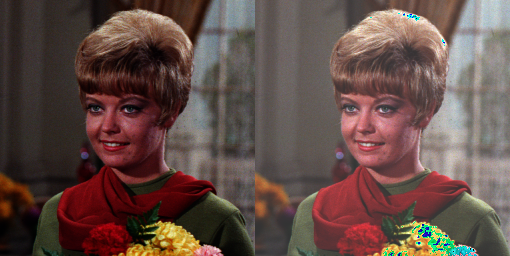

In [15]:
print(' Mengubah tingkat kecerahan citra ')
print('-------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK/Images/perempuan.png')
brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

#cara simple tanpa for loop
#brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat([original, brightness_image])
cv2_imshow(final_frame)

## **TASK**


1. Implement image inverse in your code using formula shown in the theoretical
background subsection above, giving the output shown in the following figure:


1. Inverse Citra (Negatif)
--------------------------


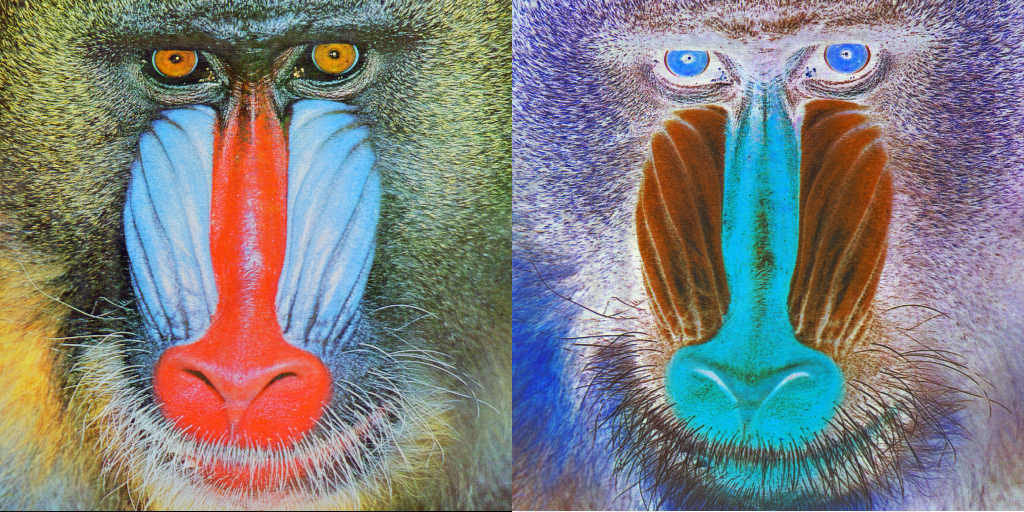

In [16]:
print('1. Inverse Citra (Negatif)')
print('--------------------------')

img = cv.imread('/content/drive/MyDrive/PCVK/Images/mandrill.tiff')

# Buat array kosong
inverse_img = np.zeros(img.shape, img.dtype)

# Akses per piksel
for y in range(img.shape[0]):
  for x in range(img.shape[1]):
    for c in range(img.shape[2]):
      inverse_img[y, x, c] = 255 - img[y, x, c]

# cara simple tanpa loop:
# inverse_img = 255 - img

# Gabungkan hasil
final = cv.hconcat([img, inverse_img])
cv2_imshow(final)


2. Implement contrast transformation in Google Collaboratory using the formula written
in the Theoretical background section, giving the output shown in the following figure:

Mengubah kontras dan tingkat kecerahan citra
--------------------------------------------
Masukkan tingkat kecerahan [-255 – 255]: 60
Masukkan kontras [1.0 – 3.0]: 1.5


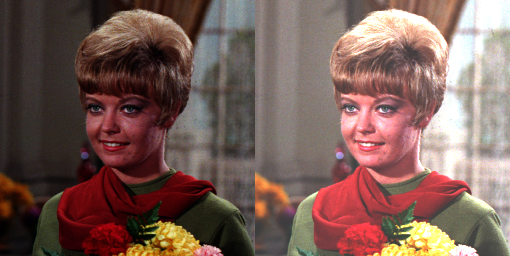

In [17]:
print('Mengubah kontras dan tingkat kecerahan citra')
print('--------------------------------------------')
try:
  brightness = int(input('Masukkan tingkat kecerahan [-255 – 255]: '))
  contrast = float(input('Masukkan kontras [1.0 – 3.0]: '))
except ValueError:
  print('Error, input tidak valid')
  brightness = 0
  contrast = 1.0

img = cv.imread('/content/drive/MyDrive/PCVK/Images/perempuan.png')

# Terapkan transformasi kontras + brightness
new_image = np.zeros(img.shape, img.dtype)

for y in range(img.shape[0]):
  for x in range(img.shape[1]):
    for c in range(img.shape[2]):
      value = contrast * img[y,x,c] + brightness
      new_image[y,x,c] = np.clip(value, 0, 255)

# cara simple tanpa loop:
# new_image = cv.convertScaleAbs(img, alpha=contrast, beta=brightness)

# Gabungkan hasil
final = cv.hconcat([img, new_image])
cv2_imshow(final)


3. Implement transformation of logarithmic brightness on Google Colaboratory using the
formula written in the Theoretical Background Reviews, generating output shown in
the following figure:

Mengubah tingkat kecerahan citra dengan Transformasi Log
--------------------------------------------------------
Masukkan nilai kecerahan: 40


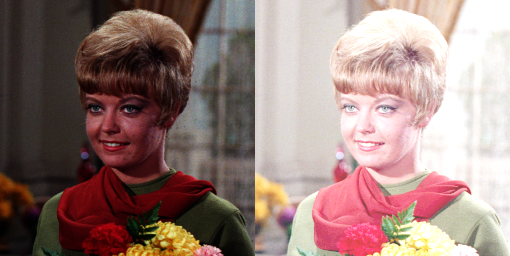

In [18]:
print('Mengubah tingkat kecerahan citra dengan Transformasi Log')
print('--------------------------------------------------------')

try:
  brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
  print('Error, input tidak valid')
  brightness = 0

img = cv.imread('/content/drive/MyDrive/PCVK/Images/perempuan.png')
log_img = np.zeros(img.shape, img.dtype)

# Akses per piksel
for y in range(img.shape[0]):
  for x in range(img.shape[1]):
    for c in range(img.shape[2]):
      # Transformasi log + brightness
      value = np.log1p(img[y, x, c]) * (255 / np.log(256)) + brightness
      log_img[y, x, c] = np.clip(value, 0, 255)



# Gabungkan hasil
final = cv.hconcat([img, log_img])
cv2_imshow(final)

4. Implement grayscale transformation using the averaging, lightness, and luminance
method on Google Colaboratory using the formula written in the Theoretical
Background Reviews, generating output as follows :

4. Konversi ke Grayscale (Averaging, Lightness, Luminance)
----------------------------------------------------------
a. Averaging


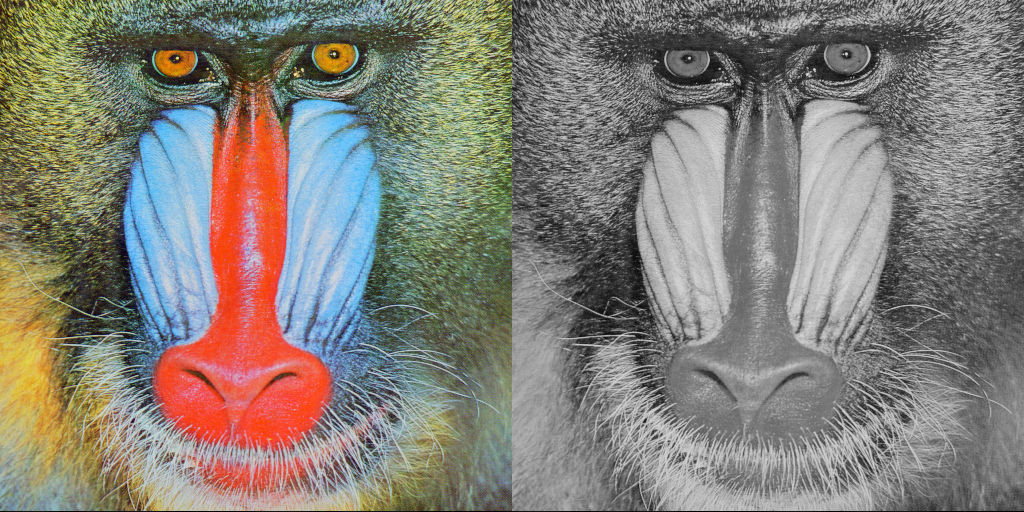

b. Lightness


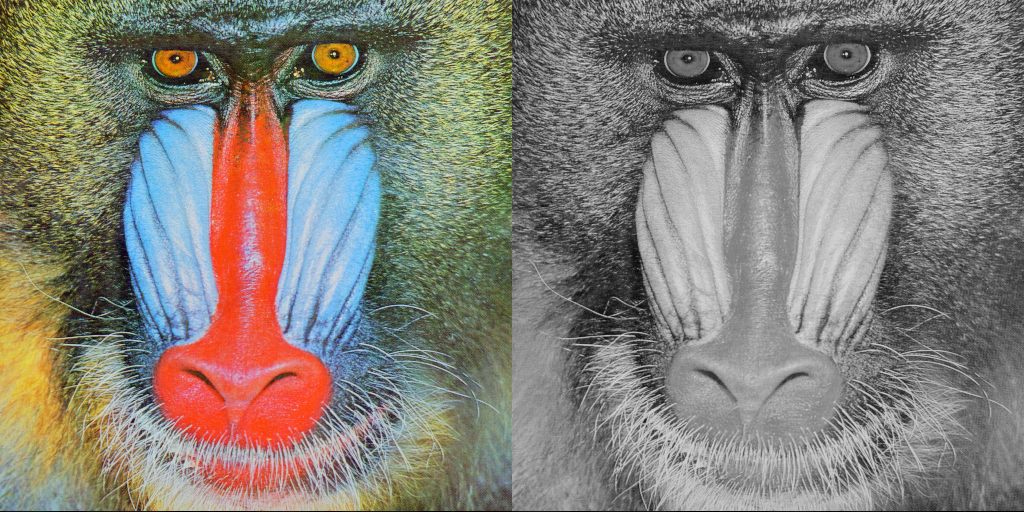

c. Luminance


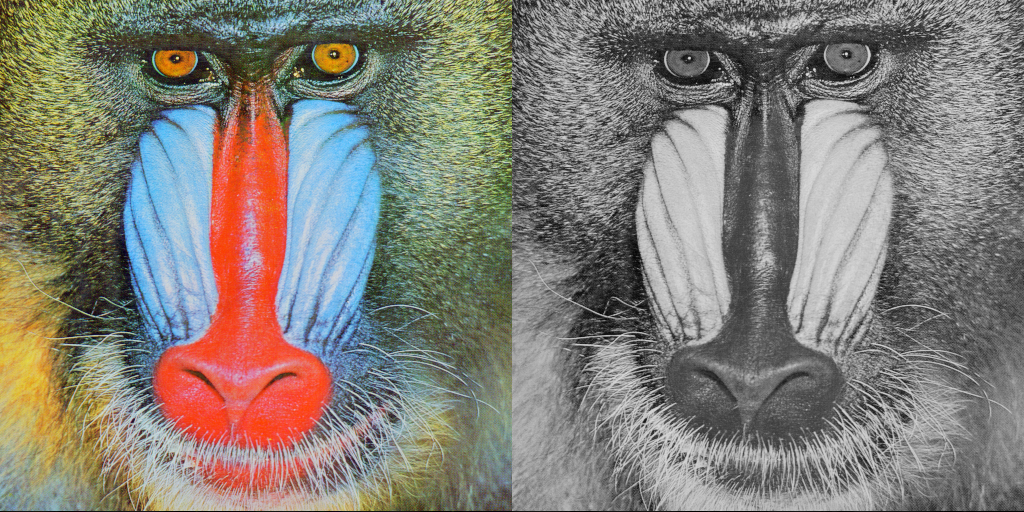

In [19]:
print('4. Konversi ke Grayscale (Averaging, Lightness, Luminance)')
print('----------------------------------------------------------')

img = cv.imread('/content/drive/MyDrive/PCVK/Images/mandrill.tiff')

# Buat array kosong untuk tiap metode
gray_avg = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
gray_light = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
gray_lumi = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)

# Loop per piksel
for y in range(img.shape[0]):
  for x in range(img.shape[1]):
    R, G, B = img[y, x]

    # Averaging
    gray_avg[y, x] = np.clip((int(R) + int(G) + int(B)) / 3, 0, 255)
    # Lightness
    gray_light[y, x] = np.clip((int(max(R, G, B)) + int(min(R, G, B))) / 2, 0, 255)
    # Luminance
    gray_lumi[y, x] = np.clip(0.21*int(R) + 0.72*int(G) + 0.07*int(B), 0, 255)

# Gabungkan hasil dengan citra asli
final_avg   = cv.hconcat([img, cv.cvtColor(gray_avg, cv.COLOR_GRAY2BGR)])
final_light = cv.hconcat([img, cv.cvtColor(gray_light, cv.COLOR_GRAY2BGR)])
final_lumi  = cv.hconcat([img, cv.cvtColor(gray_lumi, cv.COLOR_GRAY2BGR)])

print("a. Averaging")
cv2_imshow(final_avg)

print("b. Lightness")
cv2_imshow(final_light)

print("c. Luminance")
cv2_imshow(final_lumi)

5. Show certain colors in the image, and change other colors to grayscale. For example, show the blue color in the image input and change the parts other which is not colored blue into grayscale as in the example below:


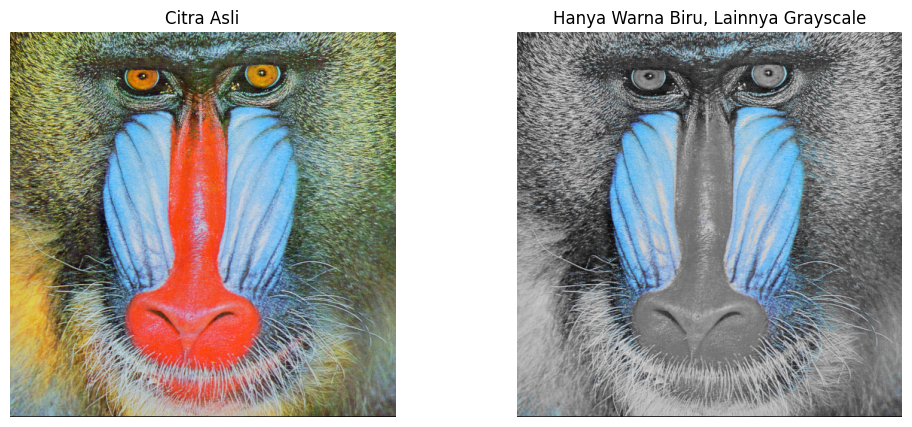

In [20]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/mandrill.tiff')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Konversi ke HSV agar lebih mudah mendeteksi warna biru
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)

# Tentukan rentang warna biru (hue sekitar 100-140)
lower_blue = np.array([90, 50, 50])
upper_blue = np.array([140, 255, 255])

# Buat mask untuk warna biru
mask = cv.inRange(hsv, lower_blue, upper_blue)

# Buat citra grayscale
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_bgr = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)

# Gabungkan: jika pixel biru, ambil dari img_rgb, jika tidak ambil dari gray_bgr
result = np.where(mask[:, :, np.newaxis] == 255, img_rgb, gray_bgr)

# Tampilkan hasil
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Citra Asli")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(result)
plt.title("Hanya Warna Biru, Lainnya Grayscale")
plt.axis("off")

plt.show()